In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon, beta
from scipy.ndimage import gaussian_filter

from sklearn.model_selection import train_test_split

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil, sys
from pathlib import Path
import json
import subprocess
from tqdm import tqdm

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

sys.path.append("../")
import mpscr_models_flexible as mpscr
import pwexp_flexible as pwexp
import gndr_utils as utils
import mps

I0000 00:00:1786113035.026806   16729 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786113036.083028   16729 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Thetaflow version: 0.0.35


This notebook simply aims to test the functions developed for fit_single_simulation.py and fit_simulations.py files.

In [23]:
def fit_model(dist, model_type, y_train, delta_train, x_train, y_test, delta_test, x_test, fixed_q = 0.0, epochs = 5000):
    weibull_spec = mpscr.BaseWeibull()
    base_spec = weibull_spec

    dist = dist.lower()
    if(dist == "poisson"):
        model_spec = mpscr.MPSPoisson()
    elif(dist == "bin" or dist == "binomial"):
        model_spec = mpscr.MPSBinomial(fixed_q)
    elif(dist == "negbin"):
        model_spec = mpscr.MPSNegBinomial()
    elif(dist == "geometric"):
        model_spec = mpscr.MPSNegBinomial(1.0)
    elif(dist == "log" or dist == "logarithmic"):
        model_spec = mpscr.MPSLogarithmic()
    elif(dist == "rgp"):
        model_spec = mpscr.MPSRGP()
    else:
        raise Exception("Please, provide a valid subfamily name.")

    data_train = [y_train, delta_train]
    if(model_type == "simple"):
        with tf.device("/CPU:0"):
            model = mpscr.build_simple_mpscr_model(y_train, delta_train, model_spec, base_spec, seed = 10 )
            model.train_model(epochs = 5000, x = None, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, force_training_validation = True,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                              optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)
            model_results = model.get_survival_cure(y_train, delta_train, y_test, delta_test, ngrid = 100)
    elif(model_type == "medium"):
        medium_neural_network, medium_neural_network_call, medium_neural_network_call_nolast = build_neural_network_structure(1)
        with tf.device("/GPU:0"):
            model = mpscr.build_medium_mpscr_model(y_train, delta_train, x_train.shape[1:], model_spec, base_spec,
                                                   neural_network = medium_neural_network, neural_network_call = medium_neural_network_call,
                                                   neural_network_call_nolast = medium_neural_network_call_nolast,
                                                   seed = 10)
            model.train_model(epochs = 5000, x = x_train, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)
            model_results = model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = 100)
    elif(model_type == "flexible"):
        flexible_neural_network, flexible_neural_network_call, flexible_neural_network_call_nolast = build_neural_network_structure(base_spec.n_parameters+1)
        with tf.device("/GPU:0"):
            model = mpscr.build_flexible_mpscr_model(y_train, delta_train, x_train.shape[1:], model_spec, base_spec,
                                                     neural_network = flexible_neural_network, neural_network_call = flexible_neural_network_call,
                                                     neural_network_call_nolast = flexible_neural_network_call_nolast,
                                                     seed = 10)
            model.train_model(epochs = 5000, x = x_train, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)
            model_results = model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = 100)
    else:
        print("Please, provide a valid model type (simple, medium, flexible).")
    
    return model, model_results

In [24]:
def fit_single_simulation(file_index, dist, model_type, fixed_q = 0.0, epochs = 5000, verbose = 1):
    filename = "fit_single_simulation.py"

    file_index = sys.argv[1]
    dist = sys.argv[2]
    model_type = sys.argv[3]
    fixed_q = float(sys.argv[4])
    epochs = int(sys.argv[5])
    
    command = [sys.executable, "fit_single_simulation.py", param1, param2]
    
    if(verbose > 0):
        subprocess_result = subprocess.run(command)
    else:
        # If verbose = 0, supresses all possible outputs from the file
        subprocess_result = subprocess.run(
            command,
            stdout = subprocess.DEVNULL,
            stderr = subprocess.DEVNULL
        )

In [32]:
(1-df_train["delta"]).mean()

np.float64(0.856)

In [31]:
df_train["cured"].mean()

np.float64(0.848)

(0.0, 1.05)

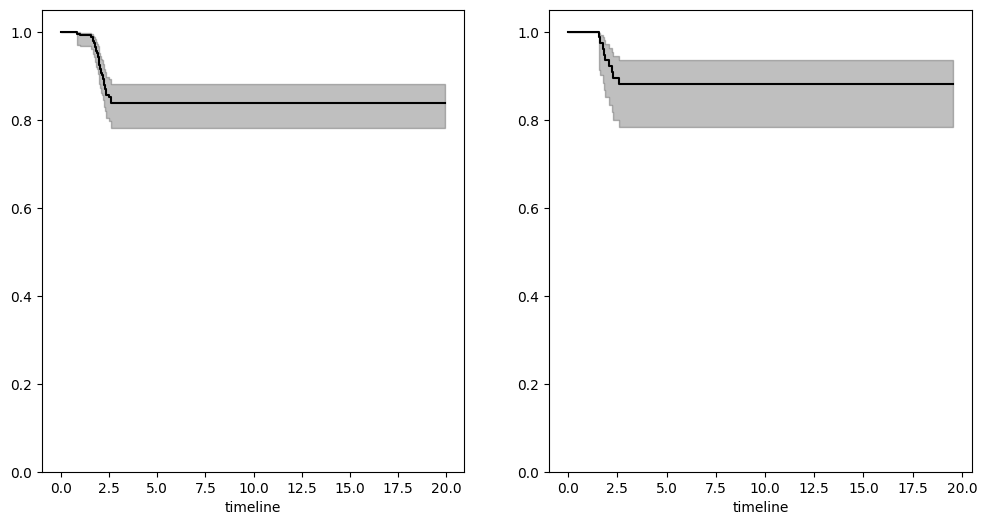

In [33]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

km = lifelines.KaplanMeierFitter()
km.fit(y_train, delta_train)
km.plot(ax = ax[0], ci_show = True, show_censors = False, label = "Kaplan-Meier", color = "black", legend = False)

km = lifelines.KaplanMeierFitter()
km.fit(y_test, delta_test)
km.plot(ax = ax[1], ci_show = True, show_censors = False, label = "Kaplan-Meier", color = "black", legend = False)

ax[0].set_ylim(0, 1.05)
ax[1].set_ylim(0, 1.05)

In [25]:
file_index = 1
n = 250
dist = "Poisson"
model_type = "simple"

data_dir = "Simulation Data/{}/n{}/{}".format(dist, n, file_index)
df = pd.read_csv("{}/df.csv".format(data_dir))
df_train = df.loc[df["set"] == "Train", :].iloc[:,1:]
df_test = df.loc[df["set"] == "Test", :].iloc[:,1:]

y_train = df_train["y"].to_numpy()
delta_train = df_train["delta"].to_numpy()
y_test = df_test["y"].to_numpy()
delta_test = df_test["delta"].to_numpy()

x_train = np.load("{}/train_imgs.npz".format(data_dir))["images"]
x_test = np.load("{}/test_imgs.npz".format(data_dir))["images"]

model, model_results = fit_model(dist, model_type, y_train, delta_train, x_train, y_test, delta_test, x_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 688 / 5000 ]  | Avg. Train NLL:  nan | Best Avg. Train NLL:  0.701036692 | Avg. Validation NLL:  0.738839686 | Speed:  0.00129465  epoch/s    | Elapsed Time:  0.890719175  s   63  s      
[!] FATAL: Gradients exploded to NaN/Inf at Epoch: 689
Optimizing... Epoch: [ 689 / 5000 ]  | Avg. Train NLL:  nan | Best Avg. Train NLL:  0.701036692 | Avg. Validation NLL:  0.738839686 | Speed:  0.00129443221  epoch/s    | Elapsed Time:  0.891863823  s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 1.868 seconds.


/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2755: RuntimeWarning: Covariance matrix could not be computed because the log-likelihood Hessian is singular (or near singular).
The model may not be identified.

  warnings.warn(
